In [1]:
import os
import math
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm import tqdm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from torch.optim.lr_scheduler import ReduceLROnPlateau


# -------------------------
# CONFIG
# -------------------------
DATA_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Dataset_crop30_left_top"
OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Hybrid_baseline/Outputs/2"
BEST_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_hybrid_cnn_transformer.pth")

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5
NUM_CLASSES = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.backends.cudnn.benchmark = True


# -------------------------
# TRANSFORMS
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# -------------------------
# DATASETS
# -------------------------
train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("Classes:", train_dataset.classes)


# -------------------------
# MODEL: CNN -> TRANSFORMER
# -------------------------
class CNNTransformerHybrid(nn.Module):
    def __init__(
        self,
        num_classes=3,
        embed_dim=256,
        num_heads=8,
        num_layers=4,
        dropout=0.1
    ):
        super().__init__()

        # Pretrained CNN stem (DenseNet121)
        backbone = models.densenet121(
            weights=models.DenseNet121_Weights.IMAGENET1K_V1
        )
        self.cnn = backbone.features  # output: [B, 1024, H, W]

        # Project CNN channels into transformer embedding dimension
        self.proj = nn.Conv2d(1024, embed_dim, kernel_size=1)

        # For 224x224 inputs with DenseNet121 features, output is typically 7x7
        # -> 49 tokens + 1 CLS token
        self.num_tokens = 49
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.cnn(x)              # [B, 1024, 7, 7]
        x = F.relu(x, inplace=True)
        x = self.proj(x)             # [B, embed_dim, 7, 7]

        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # [B, 49, embed_dim]

        cls_tokens = self.cls_token.expand(B, -1, -1)  # [B, 1, embed_dim]
        x = torch.cat((cls_tokens, x), dim=1)          # [B, 50, embed_dim]

        x = x + self.pos_embed
        x = self.pos_drop(x)

        x = self.transformer(x)
        x = self.norm(x[:, 0])       # CLS token
        x = self.head(x)
        return x


model = CNNTransformerHybrid(num_classes=NUM_CLASSES).to(DEVICE)
print(model)


# -------------------------
# LOSS / OPTIMIZER / SCHEDULER
# -------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


# -------------------------
# TRAIN / EVAL FUNCTIONS
# -------------------------
def run_eval(loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    return total_loss / max(1, len(loader)), acc, precision, recall, f1, all_labels, all_preds


def train_one_epoch():
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_loader, desc="Training", leave=False):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / max(1, len(train_loader))


Classes: ['COVID', 'Normal', 'Viral Pneumonia']
CNNTransformerHybrid(
  (cnn): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): Batch

/var/folders/dh/3f_yt29x3ts2265xcpl29q_80000gn/T/ipykernel_94529/2737747226.py:158: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [2]:
# -------------------------
# TRAINING LOOP
# -------------------------
best_val_f1 = 0.0
early_stop_counter = 0

train_losses = []
val_losses = []
val_accs = []
val_f1s = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch()
    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = run_eval(val_loader)

    scheduler.step(val_f1)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val Prec   : {val_prec:.4f}")
    print(f"Val Recall : {val_rec:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        early_stop_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_DIR)
        print("Best model saved.")
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("Early stopping triggered.")
            break


Training:   0%|                                          | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                                                


Epoch 1/25
Train Loss : 0.3932
Val Loss   : 0.3333
Val Acc    : 0.8550
Val Prec   : 0.8844
Val Recall : 0.8550
Val F1     : 0.8494
Best model saved.


Training:   0%|                                          | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                                                


Epoch 2/25
Train Loss : 0.2080
Val Loss   : 0.1165
Val Acc    : 0.9533
Val Prec   : 0.9539
Val Recall : 0.9533
Val F1     : 0.9535
Best model saved.


Training:   0%|                                          | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                                                

...


Epoch 14/25
Train Loss : 0.0246
Val Loss   : 0.1371
Val Acc    : 0.9717
Val Prec   : 0.9716
Val Recall : 0.9717
Val F1     : 0.9716


Training:   0%|                                          | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                                                


Epoch 15/25
Train Loss : 0.0069
Val Loss   : 0.1430
Val Acc    : 0.9717
Val Prec   : 0.9718
Val Recall : 0.9717
Val F1     : 0.9717


Training:   0%|                                          | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
                                                                                


Epoch 16/25
Train Loss : 0.0024
Val Loss   : 0.1817
Val Acc    : 0.9717
Val Prec   : 0.9717
Val Recall : 0.9717
Val F1     : 0.9715
Early stopping triggered.


In [3]:
# TEST EVALUATION

model.load_state_dict(torch.load(BEST_MODEL_DIR, map_location=DEVICE))
test_loss, test_acc, test_prec, test_rec, test_f1, all_labels, all_preds = run_eval(test_loader)

print("\n===== TEST RESULTS =====")
print(f"Test Loss   : {test_loss:.4f}")
print(f"Accuracy    : {test_acc:.4f}")
print(f"Precision   : {test_prec:.4f}")
print(f"Recall      : {test_rec:.4f}")
print(f"F1 Score    : {test_f1:.4f}")

print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes,
        zero_division=0
    )
)


/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



===== TEST RESULTS =====
Test Loss   : 0.0646
Accuracy    : 0.9770
Precision   : 0.9772
Recall      : 0.9770
F1 Score    : 0.9771

Classification Report:

                 precision    recall  f1-score   support

          COVID       0.97      0.99      0.98       145
         Normal       0.97      0.97      0.97       145
Viral Pneumonia       1.00      0.98      0.99       145

       accuracy                           0.98       435
      macro avg       0.98      0.98      0.98       435
   weighted avg       0.98      0.98      0.98       435



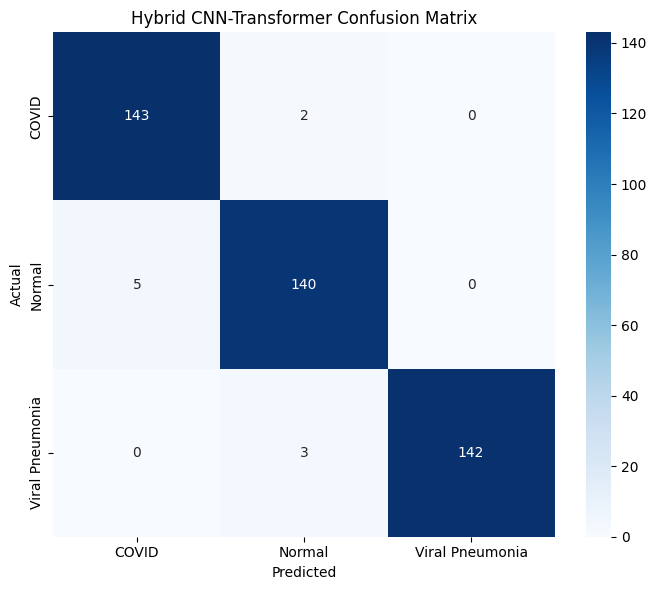

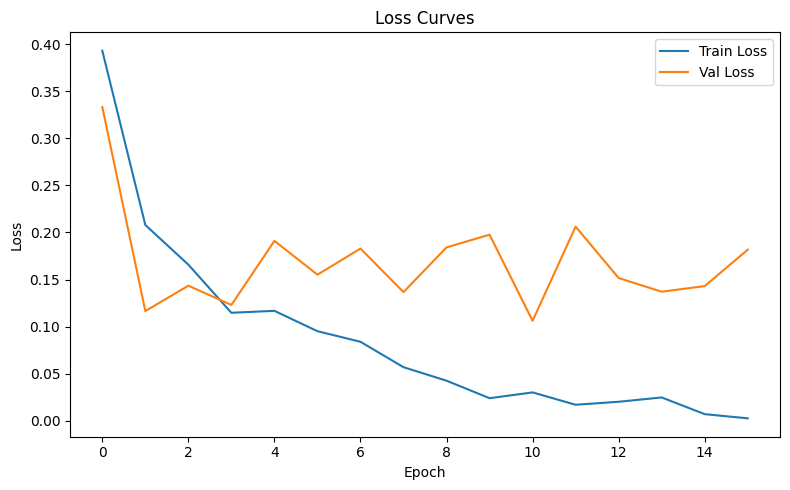

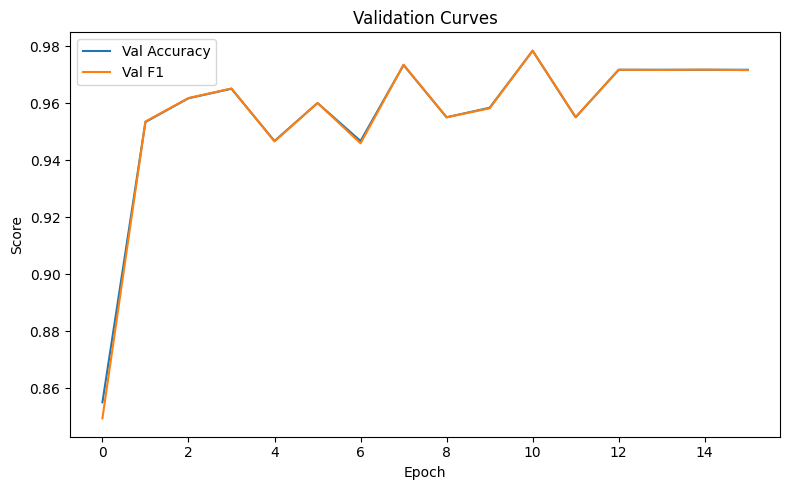

In [4]:
# -------------------------
# CONFUSION MATRIX
# -------------------------
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid CNN-Transformer Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_confusion_matrix.png"), dpi=200)
plt.show()


# -------------------------
# TRAINING CURVES
# -------------------------
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_loss_curve.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(val_accs, label="Val Accuracy")
plt.plot(val_f1s, label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Curves")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_val_curves.png"), dpi=200)
plt.show()


####
# Grad-CAM model

In [54]:
# GRAD-CAM FOR HYBRID CNN-ViT MODEL

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import numpy as np
import os
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

SAVE_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/2/Hybrid_GradCam"

# ----------------------------------------------------------
# CNN target layer
# Last DenseNet convolution before transformer projection
# ----------------------------------------------------------

target_layers = [
    model.proj
]
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

model.eval()

for i in image_dataset:

    image_path = os.path.join(
        IMG_DIR,
        i
    )

    input_tensor, rgb_img = load_image(
        image_path
    )

    input_tensor = input_tensor.to(
        DEVICE
    )


    with torch.no_grad():
        pred_class = model(input_tensor).argmax(1).item()
    
    targets = [
        ClassifierOutputTarget(pred_class)
    ]
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]
    
    # Save raw saliency map
    np.save(
        os.path.join(
            SAVE_DIR,
            "Saliency_maps",
            f"{os.path.splitext(i)[0]}.npy"
        ),
        grayscale_cam
    )

    # Overlay heatmap
    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )
    
    save_path = os.path.join(SAVE_DIR, i)
    cv2.imwrite(
        save_path,
        cv2.cvtColor(
            visualization,
            cv2.COLOR_RGB2BGR
        )
    )
    break

print("All Grad-CAM images saved successfully.")

True
All Grad-CAM images saved successfully.


In [62]:
print(torch.is_grad_enabled())
print(next(model.parameters()).requires_grad)
print(grayscale_cam.min(), grayscale_cam.max())
print(gradient.abs().mean())
gradient.abs().max()

True
True
0.0 0.0
tensor(0.)


tensor(0.)

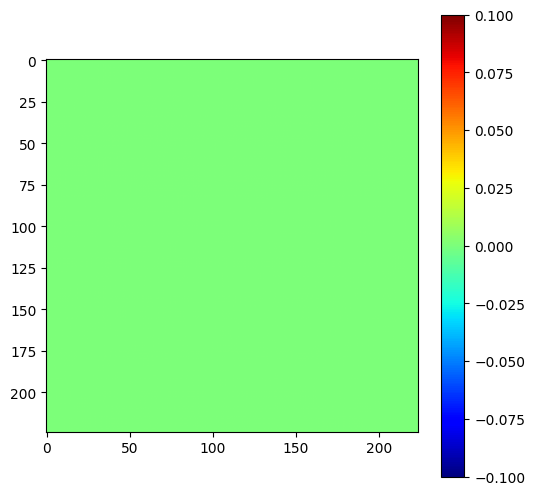

In [51]:
plt.figure(figsize=(6,6))
plt.imshow(grayscale_cam, cmap="jet")
plt.colorbar()
plt.show()